In [70]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags
import sympy as sy
from numpy import linspace, ones
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.pylab import *
from time import time
from mpl_toolkits import mplot3d
from scipy.fftpack import rfft, irfft, dst, dct, idst

In [71]:
x = sy.symbols('x')
#u = 5 + x*sy.sin(2*sy.pi*x) * x*x*sy.cos(2*sy.pi*x)
#v = sy.cos(2*sy.pi*x)**2 * sy.sin(2*sy.pi*x) 

#u = sy.sin(2*sy.pi * x)
#v = sy.cos(2*sy.pi * x)

u = (x-x**2)**2
v = (x-x**2)**4
f = -u.diff(x, 2) + u - v
g = -v.diff(x, 2) + v + u

f = sy.lambdify(x, f)
g = sy.lambdify(x, g)

u = sy.lambdify(x, u)
v = sy.lambdify(x, v)

In [72]:

# u = lambda x : 5 + x*np.sin(2*np.pi*x) + x*x*np.cos(2*np.pi*x)
# v = lambda x : np.cos(2*np.pi*x)**2 + np.sin(2*np.pi*x) 

# f = lambda x : 4*np.pi**2*x**2*np.cos(2*pi*x) + 8*np.pi*x*np.sin(2*np.pi*x) + 4*np.pi**2*x*np.sin(2*np.pi*x) - 4*np.pi*np.cos(2*np.pi*x) - 2*np.cos(2*np.pi*x) + u(x) - v(x)

# g = lambda x : -8*pi**2*sin(2*pi*x)**2 + 4*pi**2*sin(2*pi*x) + 8*pi**2*cos(2*pi*x)**2 +  v(x) + u(x)

L = 1

def resol(N):
    dx = L/N

    #lambda_k = lambda k : ((2 * (k+1) * np.pi) / L)**2


    X = np.linspace(0, L-dx, N)

    F_chap = rfft(f(X))
    G_chap = rfft(g(X))

    U_chap = np.zeros(len(F_chap))
    V_chap = np.zeros(len(F_chap))

    kk=zeros(N)
    kk[1::2]=range(1,int(N/2)+1)
    kk[0::2]=range(0,int(N/2))
    lambda_k = ((2 * (kk) * np.pi) / L)**2
    print(kk)

    U_chap = (F_chap * (lambda_k + 1) + G_chap) / (1 + (lambda_k + 1)**2)
    V_chap =  U_chap * (lambda_k + 1) - F_chap

    #for k in kk:


        #U_chap[k] = (F_chap[k] * (lambda_k(k) + 1) + G_chap[k]) / (1 + (lambda_k(k) +1)**2)
        #V_chap[k] = (G_chap[k] - U_chap[k]) / (lambda_k(k) + 1)



    u_approx = irfft(U_chap)
    v_approx = irfft(V_chap)

    return (sum(abs(u(X)-u_approx))/len(u_approx), sum(abs(v(X)-v_approx))/len(v_approx))

#plt.plot(u_approx)

#plt.plot(u(X))



In [73]:
#plt.plot(v(X))

#plt.plot(v_approx)

[0. 1. 1. 2. 2. 3. 3. 4. 4. 5.]
[ 0.  1.  1.  2.  2.  3.  3.  4.  4.  5.  5.  6.  6.  7.  7.  8.  8.  9.
  9. 10.]
[ 0.  1.  1.  2.  2.  3.  3.  4.  4.  5.  5.  6.  6.  7.  7.  8.  8.  9.
  9. 10. 10. 11. 11. 12. 12. 13. 13. 14. 14. 15.]
[ 0.  1.  1.  2.  2.  3.  3.  4.  4.  5.  5.  6.  6.  7.  7.  8.  8.  9.
  9. 10. 10. 11. 11. 12. 12. 13. 13. 14. 14. 15. 15. 16. 16. 17. 17. 18.
 18. 19. 19. 20.]
[ 0.  1.  1.  2.  2.  3.  3.  4.  4.  5.  5.  6.  6.  7.  7.  8.  8.  9.
  9. 10. 10. 11. 11. 12. 12. 13. 13. 14. 14. 15. 15. 16. 16. 17. 17. 18.
 18. 19. 19. 20. 20. 21. 21. 22. 22. 23. 23. 24. 24. 25.]
[ 0.  1.  1.  2.  2.  3.  3.  4.  4.  5.  5.  6.  6.  7.  7.  8.  8.  9.
  9. 10. 10. 11. 11. 12. 12. 13. 13. 14. 14. 15. 15. 16. 16. 17. 17. 18.
 18. 19. 19. 20. 20. 21. 21. 22. 22. 23. 23. 24. 24. 25. 25. 26. 26. 27.
 27. 28. 28. 29. 29. 30.]
[ 0.  1.  1.  2.  2.  3.  3.  4.  4.  5.  5.  6.  6.  7.  7.  8.  8.  9.
  9. 10. 10. 11. 11. 12. 12. 13. 13. 14. 14. 15. 15. 16. 16. 17. 17. 18.
 18

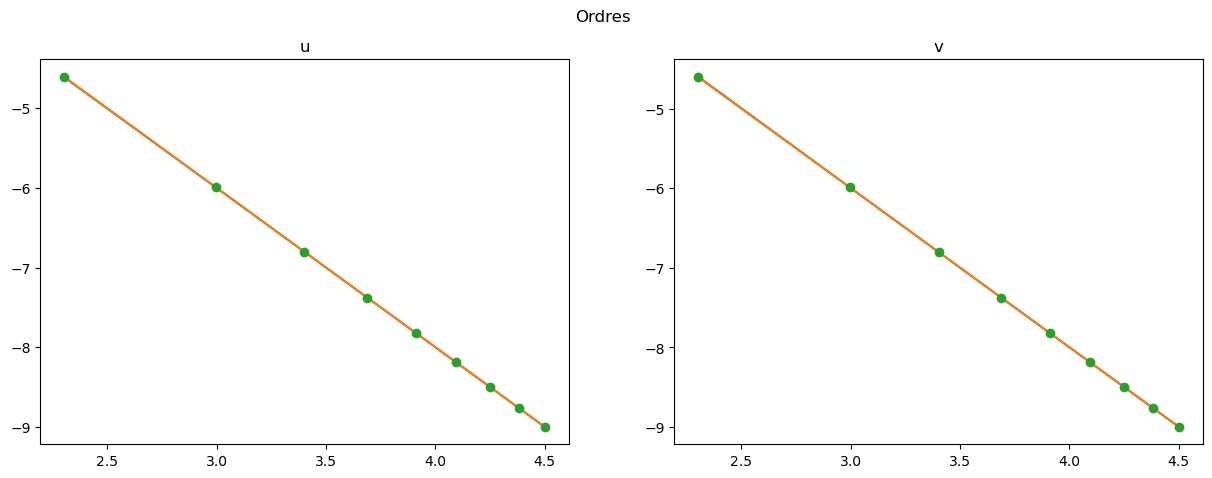

l'ordre u est :  1.9974471127009492
l'ordre v est :  2.0025373961178503


In [74]:
Ns = np.arange(10,100,10)
Err = [[],[]]
for N in Ns :
	(Eu , Ev) = resol(N)
	Err[0].append(Eu)
	Err[1].append(Ev)


fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Ordres')
axs[0].set_title('u')
axs[0].plot(np.log(Ns),np.log(Err[0]), np.log(Ns), -2*np.log(Ns))

axs[0].plot(log(Ns),log(Err[0]),'o')

axs[1].set_title('v')
axs[1].plot(log(Ns),log(Err[1]), log(Ns), -2*log(Ns))
axs[1].plot(log(Ns),log(Err[1]),'o')
plt.show()

print("l'ordre u est : ", -polyfit(log(Ns),log(Err[0]),1)[0])
print("l'ordre v est : ", -polyfit(log(Ns),log(Err[1]),1)[0])